In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [32]:
df=pd.read_csv(r"C:\Users\manas\OneDrive\Desktop\Whitecliffe\Machine Learning\Assessment\data set\animation_movies_enriched_1878_2029.csv")

In [33]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25390 entries, 0 to 25389
Data columns (total 44 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Movie_ID                    25390 non-null  int64  
 1   TMDB_ID                     25390 non-null  int64  
 2   IMDb_ID                     18482 non-null  object 
 3   Movie_Name                  25390 non-null  object 
 4   Original_Title              25390 non-null  object 
 5   Release_Year                24609 non-null  float64
 6   Release_Date                24609 non-null  object 
 7   Studio                      18541 non-null  object 
 8   All_Production_Companies    18886 non-null  object 
 9   Director                    22967 non-null  object 
 10  Country_Origin              25230 non-null  object 
 11  Original_Language           25390 non-null  object 
 12  Spoken_Languages            25390 non-null  object 
 13  Animation_Style             249

None

In [34]:
df.describe()                 # stats for numeric columns (count, mean, std, min, max, etc.)
df.describe(include='object') # overview for categorical/text columns (count, unique, top, freq)


,IMDb_ID,Movie_Name,Original_Title,Release_Date,Studio,All_Production_Companies,Director,Country_Origin,Original_Language,Spoken_Languages,...,Voice_Cast,Live_Action_Remake,Belongs_To_Collection,Poster_URL,Backdrop_URL,TMDB_URL,IMDb_URL,Decade,Era,Popularity_Tier
count,18482,25390,25390,24609,18541,18886,22967,25230,25390,25390,...,16199,25390,25390,21975,14259,25390,18482,25390,25390,25390
unique,18469,24768,24919,12461,5094,8928,11915,1019,80,631,...,14221,2,974,21941,14193,25390,18469,17,9,5
top,tt4641286,Puss in Boots,A Christmas Carol,1987-01-01,Walt Disney Productions,Walt Disney Productions,Dave Fleischer,United States of America,en,English,...,Mel Blanc,No,False,https://image.tmdb.org/t/p/w500/g9Ueh5YjZvJmva...,https://image.tmdb.org/t/p/w500/7tFOLDhZqKPact...,https://www.themoviedb.org/movie/922079,https://www.imdb.com/title/tt4641286,2010s,Modern,Obscure
freq,2,8,8,68,627,506,270,7558,13521,11826,...,322,25381,22206,9,16,1,2,5867,5867,21653


In [35]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(10))  # top columns by missing count


Profitability_ROI         24658
Budget_Million_USD        23932
Box_Office_Million_USD    23748
Collection_ID             22206
Backdrop_URL              11131
TMDB_Rating                9272
TMDB_Vote_Count            9263
Voice_Cast                 9191
IMDb_ID                    6908
IMDb_URL                   6908
dtype: int64


In [36]:
import sys
!{sys.executable} -m pip install missingno


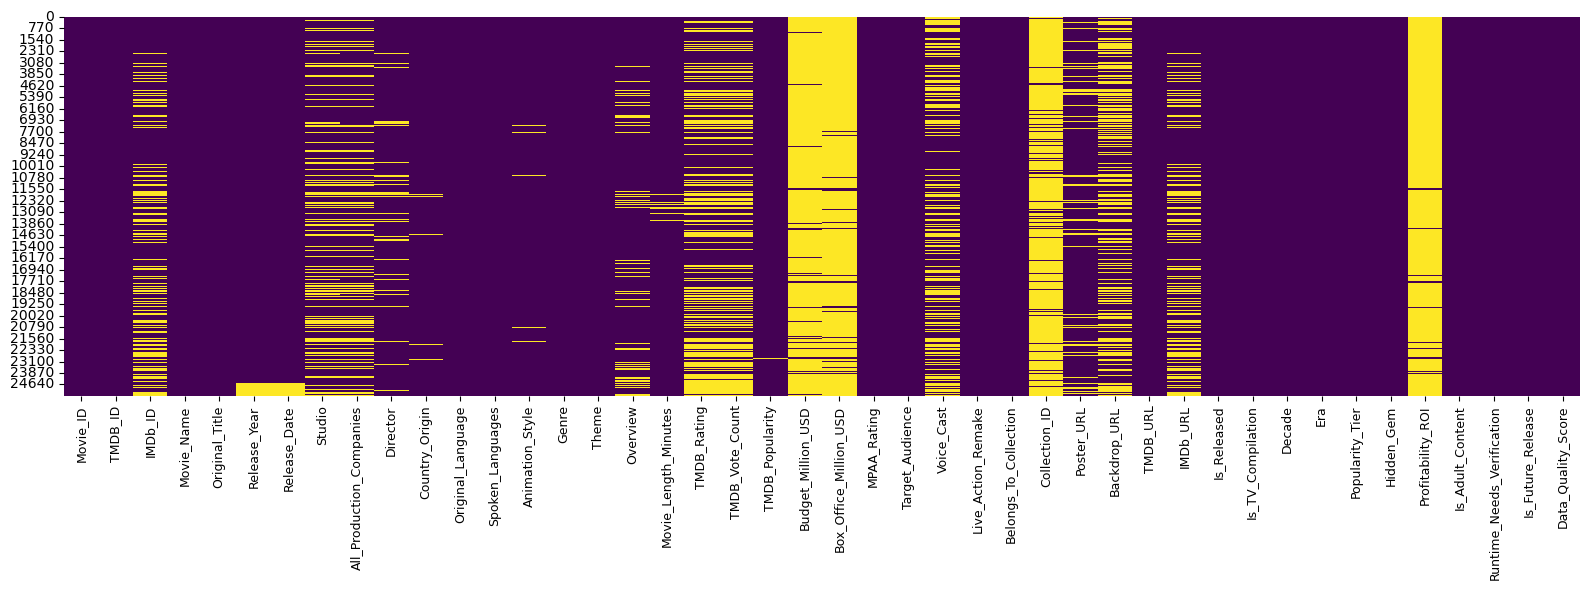

In [37]:
import warnings
# Hide the deprecation warning messages
warnings.filterwarnings('ignore', category=FutureWarning)

# 1. Force the Jupyter rendering engine to turn on
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Reset the drawing backend memory
plt.close('all')
plt.rcParams.update(plt.rcParamsDefault)

# 3. Create the drawing canvas
fig, ax = plt.subplots(figsize=(16, 6))

# 4. Generate the plot layout safely
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=9)
plt.tight_layout()

# 5. Save the local image copy
fig.savefig("missing_data_report.png", dpi=300, bbox_inches="tight")


# 6. Force display on screen
plt.show()


In [38]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")


Duplicate rows: 0


In [39]:
num_cols = ['Release_Year','TMDB_Rating','TMDB_Vote_Count',
            'Movie_Length_Minutes','Budget_Million_USD','Box_Office_Million_USD']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [40]:
df['Target_Audience'] = df['Target_Audience'].astype('category')
df['MPAA_Rating']   = df['MPAA_Rating'].astype('category')
# etc.


In [41]:
df = df[df['Movie_Length_Minutes'].between(1, 300)]


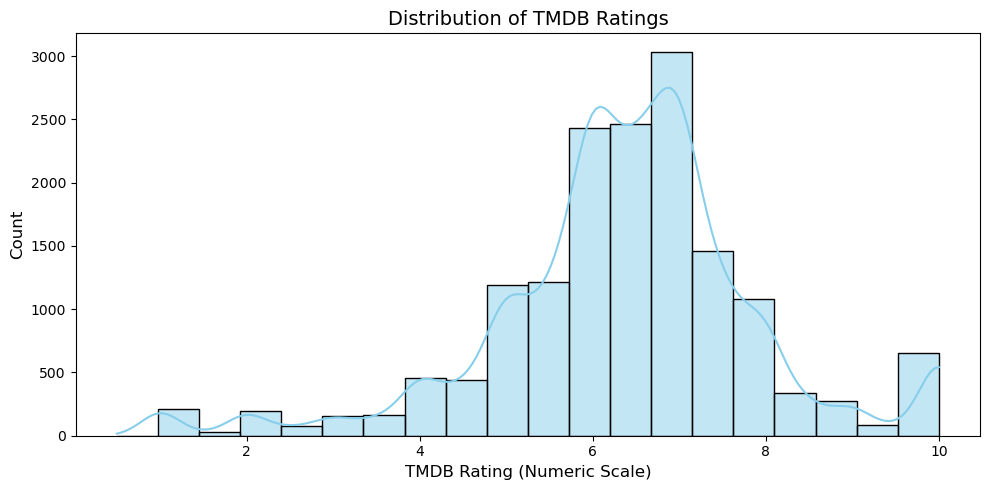

In [42]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Clean the data: Convert strings to numbers, turning errors into missing values (NaN)
df['TMDB_Rating_Clean'] = pd.to_numeric(df['TMDB_Rating'], errors='coerce')

# 2. Filter out missing data
clean_data = df['TMDB_Rating_Clean'].dropna()

# 3. Create a clean figure canvas
plt.figure(figsize=(10, 5))

# 4. Use histplot (not countplot!) to group the data into clean buckets
sns.histplot(clean_data, bins=20, kde=True, color='skyblue')

# 5. Add clean labels
plt.title('Distribution of TMDB Ratings', fontsize=14)
plt.xlabel('TMDB Rating (Numeric Scale)', fontsize=12)
plt.ylabel('Count', fontsize=12)

fig.savefig("Distribution of TMDB Ratings.png", dpi=300, bbox_inches="tight")
fig.savefig("Distribution of TMDB Ratings.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

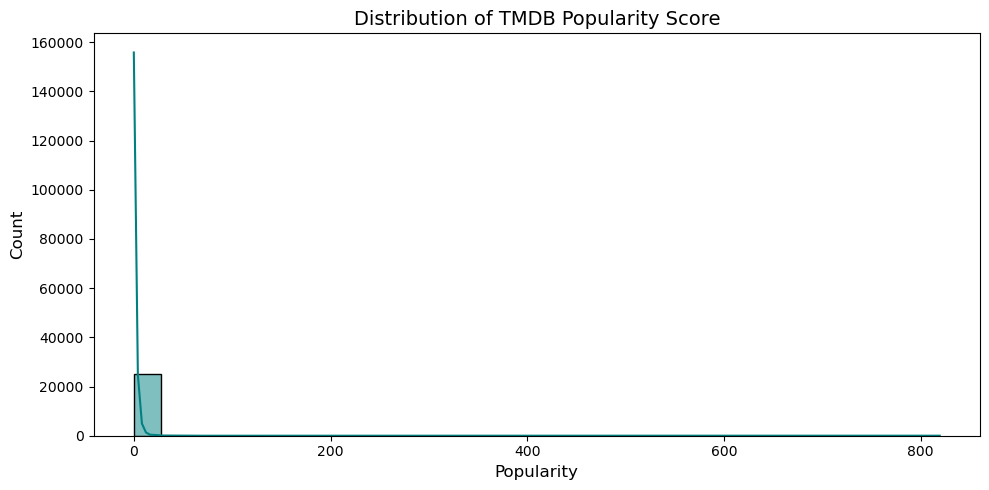

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set canvas size
plt.figure(figsize=(10, 5))

# 2. Draw the plot
sns.histplot(df['TMDB_Popularity'].dropna(), bins=30, kde=True, color="teal")

# 3. Add labels
plt.title('Distribution of TMDB Popularity Score', fontsize=14)
plt.xlabel('Popularity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()

# === 4. SAVE THE PLOTS HERE (BEFORE PLT.SHOW) ===
plt.savefig("tmdb_popularity_distribution.png", dpi=300, bbox_inches="tight")
plt.savefig("tmdb_popularity_distribution.pdf", bbox_inches="tight")
# ================================================

# 5. Display on screen last
plt.show()



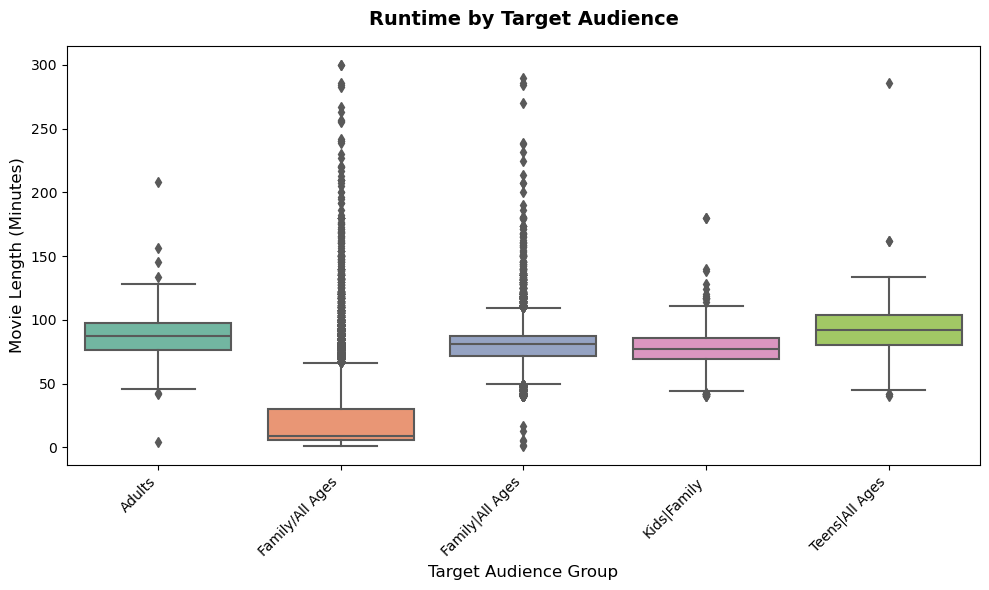

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Expand the canvas size so the categories have breathing room
plt.figure(figsize=(10, 6))

# 2. Render the distribution boxplots
sns.boxplot(x='Target_Audience', y='Movie_Length_Minutes', data=df, palette='Set2')

# 3. Add descriptive metadata
plt.title('Runtime by Target Audience', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Target Audience Group', fontsize=12)
plt.ylabel('Movie Length (Minutes)', fontsize=12)

# 4. Clean formatting: Rotate category names 45 degrees so they don't overlap
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 5. Optional: Save the file outputs to your workspace directory
plt.savefig("runtime_by_audience.png", dpi=300, bbox_inches="tight")
plt.savefig("runtime_by_audience.pdf", bbox_inches="tight")

# 6. Dispatch the canvas to the screen (Crucial)
plt.show()


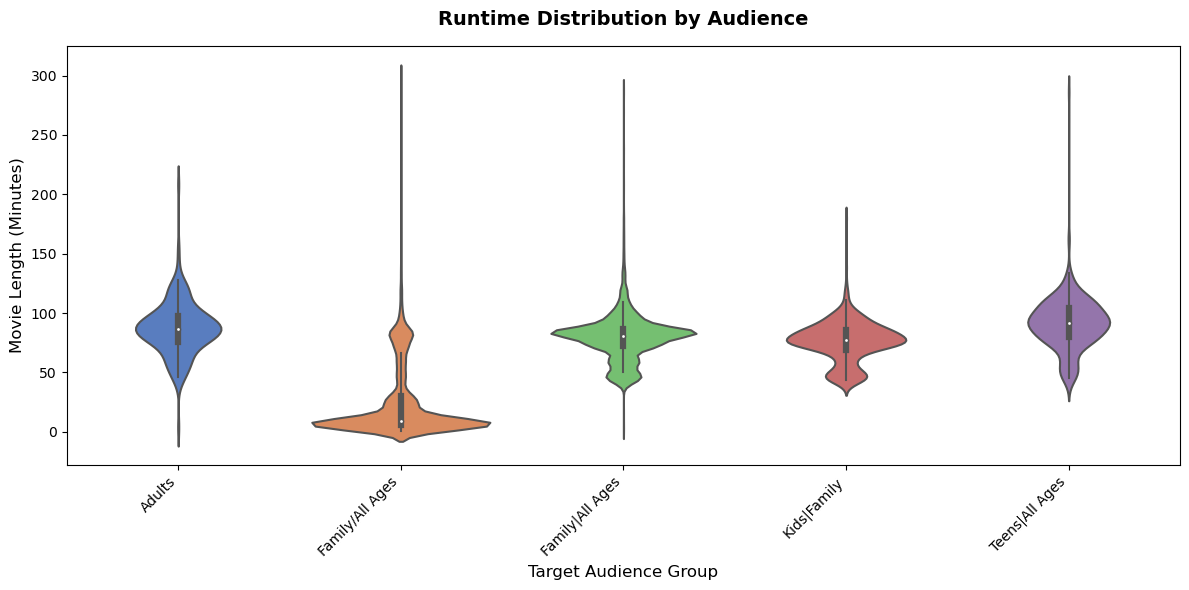

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Expand the canvas size to give the violins room to breathe
plt.figure(figsize=(12, 6))

# 2. Render the distribution violin shapes
sns.violinplot(x='Target_Audience', y='Movie_Length_Minutes', data=df, palette='muted')

# 3. Add descriptive metadata and axis titles
plt.title('Runtime Distribution by Audience', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Target Audience Group', fontsize=12)
plt.ylabel('Movie Length (Minutes)', fontsize=12)

# 4. Clean formatting: Rotate category names 45 degrees so they never overlap
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 5. Save the high-resolution file copies directly to your workspace directory
plt.savefig("runtime_violin_distribution.png", dpi=300, bbox_inches="tight")
plt.savefig("runtime_violin_distribution.pdf", bbox_inches="tight")

# 6. Dispatch the finalized canvas pipeline to the screen
plt.show()


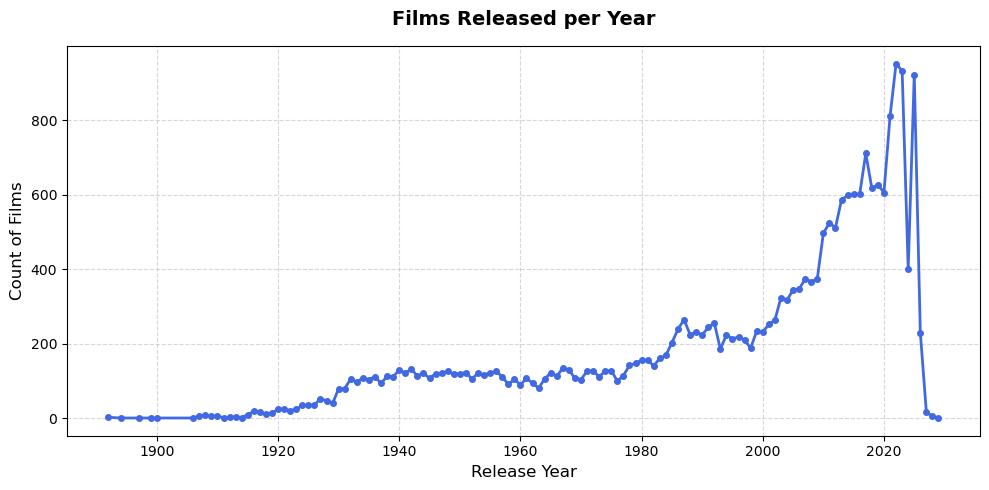

In [46]:
import matplotlib.pyplot as plt

# 1. Calculate the yearly release aggregates
counts_by_year = df.groupby('Release_Year').size()

# 2. Initialize and configure the canvas layout
plt.figure(figsize=(10, 5))

# 3. Plot the data using the pandas line-plot wrapper
counts_by_year.plot(color='royalblue', linewidth=2, marker='o', markersize=4)

# 4. Add clear labels and visual metadata
plt.title('Films Released per Year', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Count of Films', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5) # Adds a clean background grid for readability
plt.tight_layout()

# 5. Save the final visual assets
plt.savefig("films_released_per_year.png", dpi=300, bbox_inches="tight")
plt.savefig("films_released_per_year.pdf", bbox_inches="tight")

# 6. Render the completed canvas pipeline
plt.show()


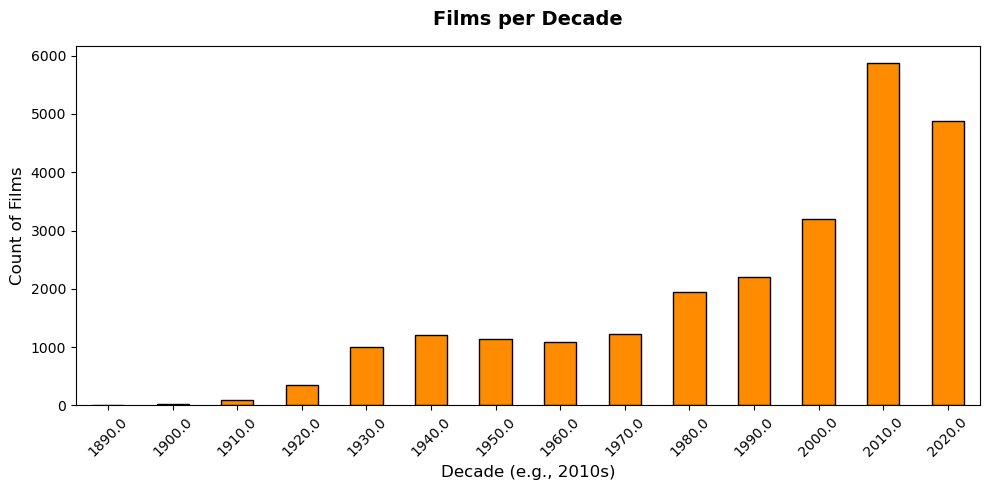

In [47]:
import matplotlib.pyplot as plt

# 1. Calculate the decade bins
df['Decade'] = (df['Release_Year'] // 10) * 10

# 2. Set up the canvas layout dimensions
plt.figure(figsize=(10, 5))

# 3. Calculate frequencies and plot as a categorical bar chart
df['Decade'].value_counts().sort_index().plot(kind='bar', color='darkorange', edgecolor='black')

# 4. Add clear labels and visual formatting
plt.title('Films per Decade', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Decade (e.g., 2010s)', fontsize=12)
plt.ylabel('Count of Films', fontsize=12)

# Rotate the decade labels slightly so they read cleanly
plt.xticks(rotation=45)
plt.tight_layout()

# 5. Save the visual assets locally
plt.savefig("films_per_decade.png", dpi=300, bbox_inches="tight")
plt.savefig("films_per_decade.pdf", bbox_inches="tight")

# 6. Render the canvas to your screen
plt.show()


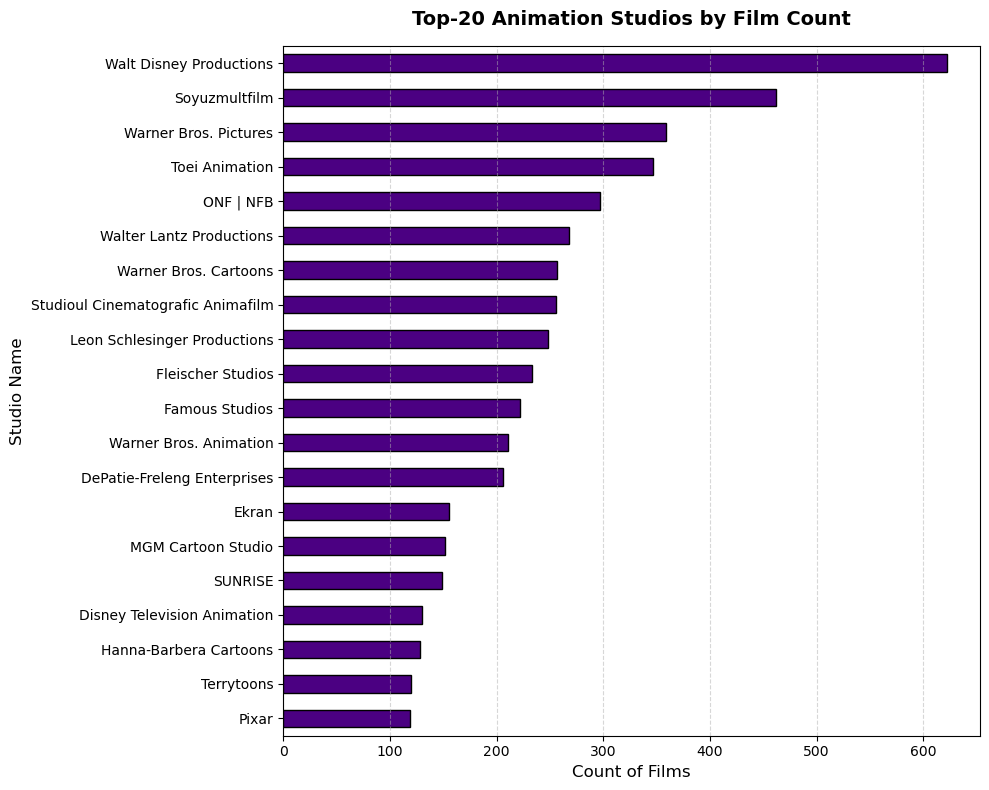

In [48]:
import matplotlib.pyplot as plt

# 1. Fetch the top 20 studios
top_studios = df['Studio'].value_counts().head(20)

# 2. Set up a taller canvas layout so 20 bars have breathing room
plt.figure(figsize=(10, 8))

# 3. Plot horizontal bars with a clean color palette
top_studios.plot(kind='barh', color='indigo', edgecolor='black')

# 4. Invert the y-axis so the highest count is at the TOP of the graph
plt.gca().invert_yaxis()

# 5. Add text labels and metadata
plt.title('Top-20 Animation Studios by Film Count', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Count of Films', fontsize=12)
plt.ylabel('Studio Name', fontsize=12)

# Add a grid along the x-axis to make tracking counts easier
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# 6. Save the final visual assets
plt.savefig("top_20_animation_studios.png", dpi=300, bbox_inches="tight")
plt.savefig("top_20_animation_studios.pdf", bbox_inches="tight")

# 7. Render to the screen
plt.show()


In [49]:
#Genre (Multi-Label) Analysis


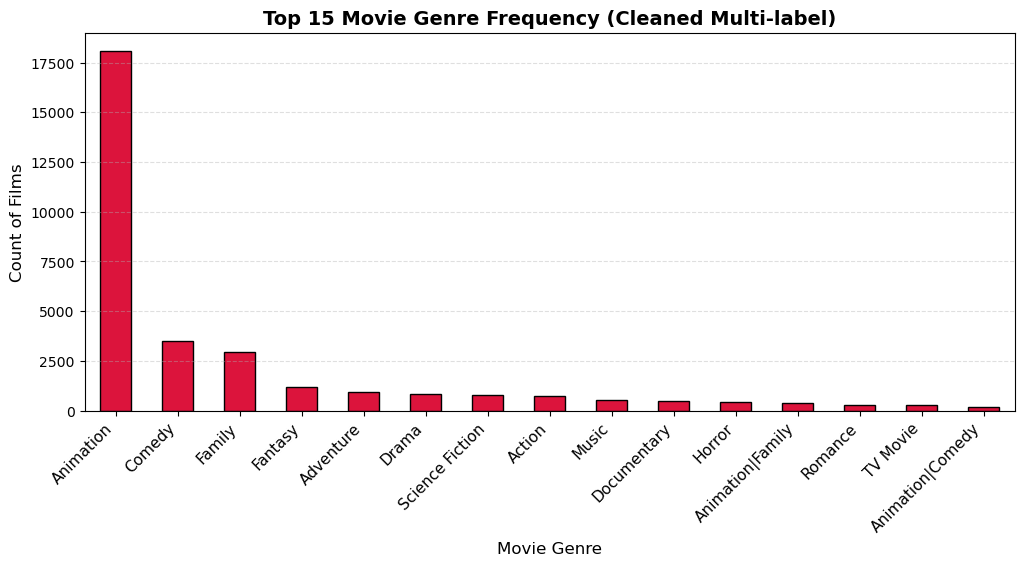

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

# 1. Split text by comma and strip empty spacing
genres_split = (
    df["Genre"]
    .dropna()
    .astype(str)
    .apply(lambda x: [g.strip() for g in x.split(",")])
)

# 2. Convert multi-labels into individual binary columns
mlb = MultiLabelBinarizer()
genre_dummies = pd.DataFrame(
    mlb.fit_transform(genres_split),
    columns=mlb.classes_,
    index=genres_split.index,
)

# 3. Sum up individual genres, sort them, and KEEP ONLY THE TOP 15
# (This completely stops the axis from clogging up!)
genre_counts = genre_dummies.sum().sort_values(ascending=False).head(15)

# 4. Initialize a clean canvas layout
plt.figure(figsize=(12, 6))

# 5. Create a clean vertical bar plot
genre_counts.plot(kind="bar", color="crimson", edgecolor="black")

# 6. Add structural labels
plt.title(
    "Top 15 Movie Genre Frequency (Cleaned Multi-label)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Movie Genre", fontsize=12)
plt.ylabel("Count of Films", fontsize=12)

# 7. Format labels safely with plenty of bottom margin room
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# 8. Use explicit layout adjusting instead of tight_layout to prevent errors
plt.subplots_adjust(bottom=0.25)

# 9. Save the clean visual report
plt.savefig("genre_frequency_top15.png", dpi=300, bbox_inches="tight")
plt.savefig("genre_frequency_top15.pdf", bbox_inches="tight")

# 10. Display the clean chart
plt.show()


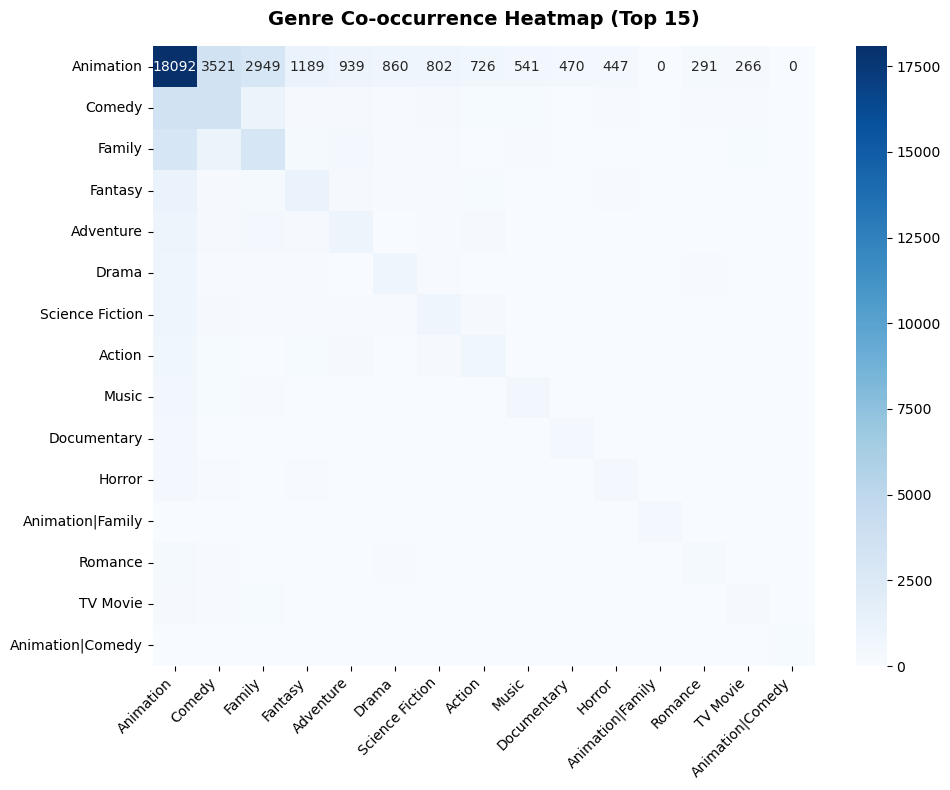

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Filter the dummy matrix to include ONLY the Top 15 genres from your previous step
top_genres = genre_counts.index
genre_dummies_filtered = genre_dummies[top_genres]

# 2. Calculate the matrix dot product using the matched subsets
co_occ = genre_dummies_filtered.T.dot(genre_dummies_filtered)

# 3. Create a clean, square-proportioned plot window
plt.figure(figsize=(10, 8))

# 4. Generate the heatmap (annot=True adds individual crossover count numbers)
sns.heatmap(co_occ, cmap="Blues", annot=True, fmt="d", cbar=True)

# 5. Add structural metadata titles
plt.title("Genre Co-occurrence Heatmap (Top 15)", fontsize=14, fontweight="bold", pad=15)

# 6. Rotate labels so they don't clip or crowd each other
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# 7. Save visual assets cleanly to your workspace
plt.savefig("genre_co_occurrence.png", dpi=300, bbox_inches="tight")
plt.savefig("genre_co_occurrence.pdf", bbox_inches="tight")

# 8. Render to screen last
plt.show()


Average genres per film: 1.55
Max genres on a single film: 8


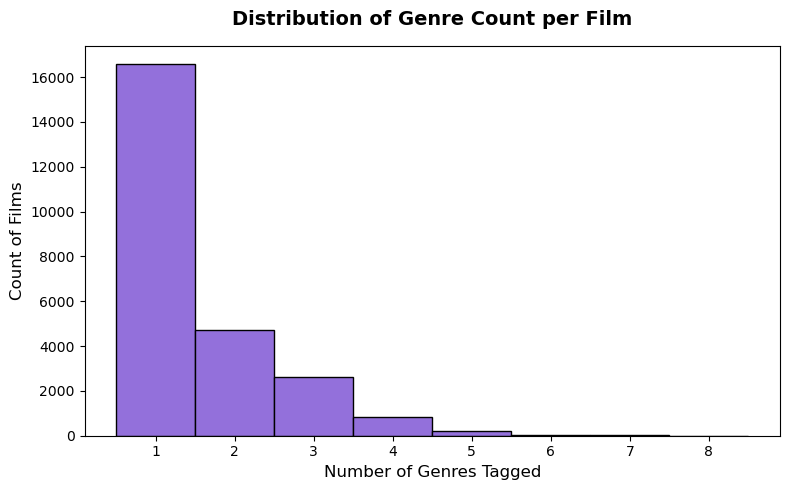

In [52]:
import matplotlib.pyplot as plt

# 1. Calculate individual label counts per row
num_labels = genres_split.apply(len)

# 2. Print out the mathematical summary metrics
print(f"Average genres per film: {num_labels.mean():.2f}")
print(f"Max genres on a single film: {num_labels.max()}")

# 3. Setup the visual chart canvas
plt.figure(figsize=(8, 5))

# 4. Generate the histogram, using center-aligned bins for clean integer bars
# (align='left' makes the bars center exactly over numbers like 1, 2, 3...)
num_labels.hist(
    bins=range(1, num_labels.max() + 2),
    color="mediumpurple",
    edgecolor="black",
    align="left",
    grid=False,
)

# 5. Add descriptive labels and formatting
plt.title("Distribution of Genre Count per Film", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Number of Genres Tagged", fontsize=12)
plt.ylabel("Count of Films", fontsize=12)

# Force the X-axis ticks to show clean whole numbers only
plt.xticks(range(1, num_labels.max() + 1))
plt.tight_layout()

# 6. Save the final visual report assets
plt.savefig("genre_count_per_film.png", dpi=300, bbox_inches="tight")
plt.savefig("genre_count_per_film.pdf", bbox_inches="tight")

# 7. Render cleanly to the screen
plt.show()


In [53]:
#text analysis

In [54]:
import sys
!{sys.executable} -m pip install wordcloud


In [55]:
pip install wordcloud


Note: you may need to restart the kernel to use updated packages.


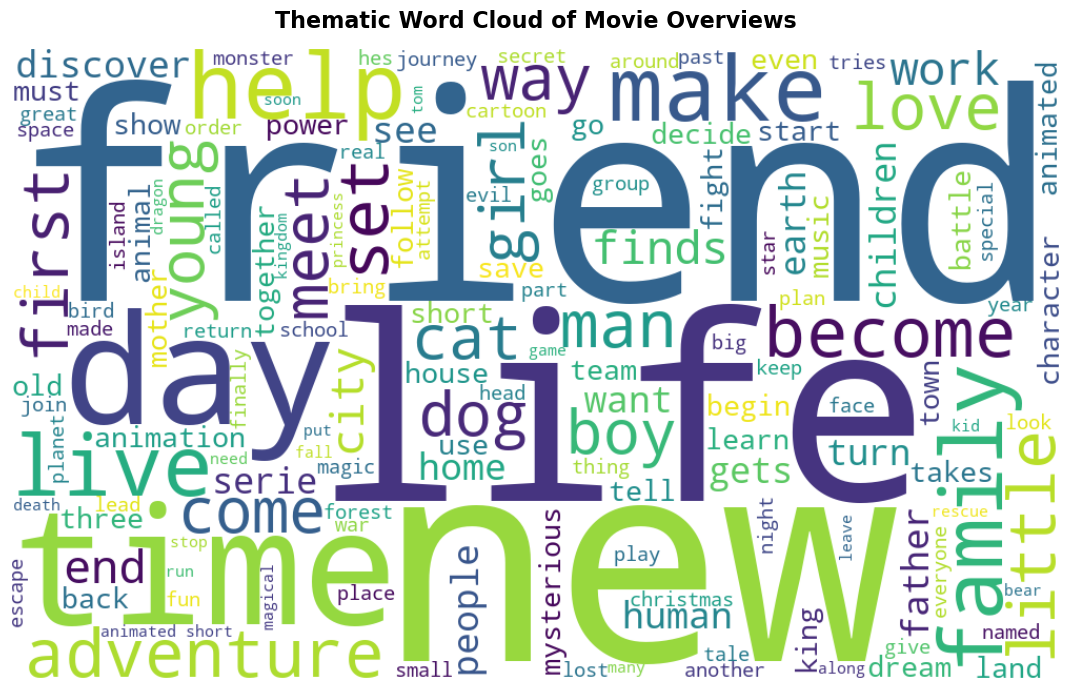

In [56]:
import re
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from wordcloud import WordCloud

# 1. Clean up text data: lowercasing, dropping empty cells, stripping punctuation
text = " ".join(df["Overview"].dropna().str.lower())
text = re.sub(r"[^a-z\s]", "", text)

# 2. Get standard English stopwords
stop = set(stopwords.words("english"))

# 3. ADD EXTRA GENERIC FILLER WORDS TO STRIP OUT (Custom Stopwords)
custom_words = {"one", "two", "world", "film", "movie", "story", "find", "take"}
stop.update(custom_words)

# 4. Filter the text data using the expanded dictionary block
words = [w for w in text.split() if w not in stop]
clean_text = " ".join(words)

# 5. Build and render the polished word cloud canvas layout
plt.figure(figsize=(12, 7))
wc = WordCloud(
    width=1000, height=600, background_color="white", max_words=150
).generate(clean_text)

plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Thematic Word Cloud of Movie Overviews",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()

# 6. Save the fresh, updated image files safely
plt.savefig("movie_overviews_wordcloud_clean.png", dpi=300, bbox_inches="tight")
plt.savefig("movie_overviews_wordcloud_clean.pdf", bbox_inches="tight")

plt.show()


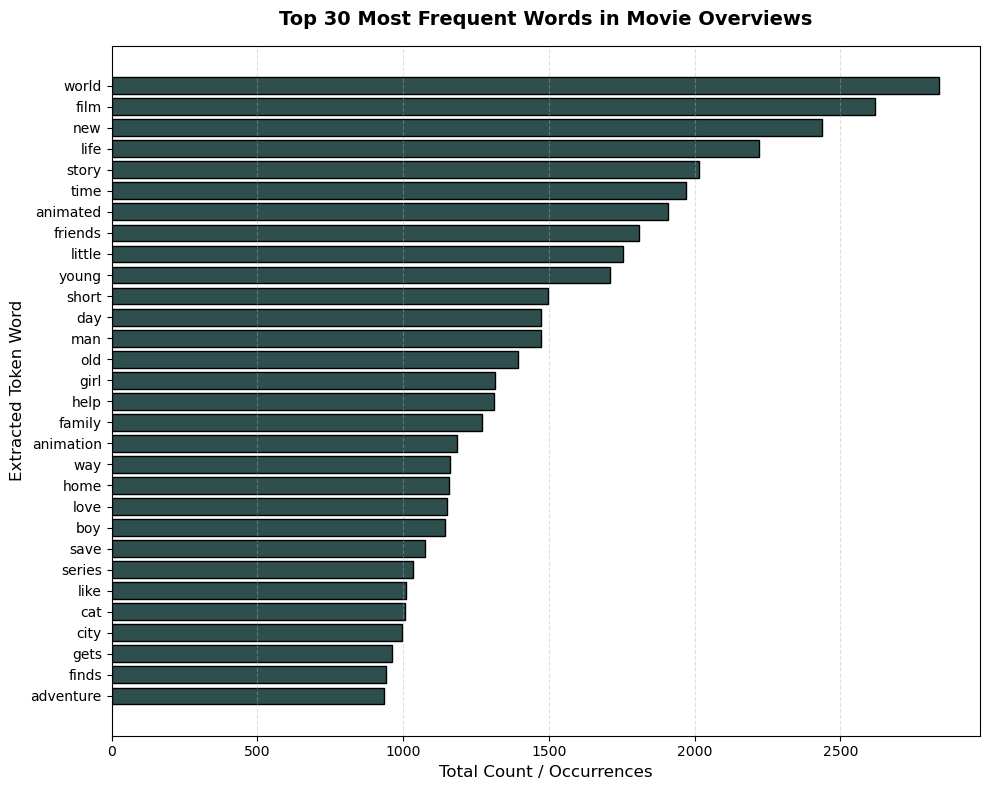

In [57]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 1. RUN THE VECTORIZER DATA PROCESSING FIRST
vectorizer = CountVectorizer(max_features=30, stop_words="english")
X = vectorizer.fit_transform(df["Overview"].dropna())
freqs = zip(vectorizer.get_feature_names_out(), X.sum(axis=0).tolist()[0])
top_words = sorted(freqs, key=lambda x: x[1], reverse=True)

# 2. UNPACK THE WORD MATRIX PAIRS
word_labels = [pair[0] for pair in top_words]
word_counts = [pair[1] for pair in top_words]

# 3. STRUCTURE A DATAFRAME FOR CLEAN SLICING
chart_df = pd.DataFrame({"Word": word_labels, "Frequency": word_counts})

# 4. INITIALIZE THE CANVAS LAYOUT (Taller height helps 30 rows breathe)
plt.figure(figsize=(10, 8))

# 5. GENERATE THE HORIZONTAL BARS
plt.barh(
    chart_df["Word"],
    chart_df["Frequency"],
    color="darkslategray",
    edgecolor="black",
)

# 6. INVERT THE Y-AXIS (Puts the #1 most frequent word at the top)
plt.gca().invert_yaxis()

# 7. ADD LABELS AND GRID
plt.title(
    "Top 30 Most Frequent Words in Movie Overviews",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Total Count / Occurrences", fontsize=12)
plt.ylabel("Extracted Token Word", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()

# 8. SAVE THE HIGH-QUALITY VISUAL ASSETS
plt.savefig("overview_word_frequencies.png", dpi=300, bbox_inches="tight")
plt.savefig("overview_word_frequencies.pdf", bbox_inches="tight")

# 9. DISPATCH CANVAS ENGINE TO THE SCREEN
plt.show()


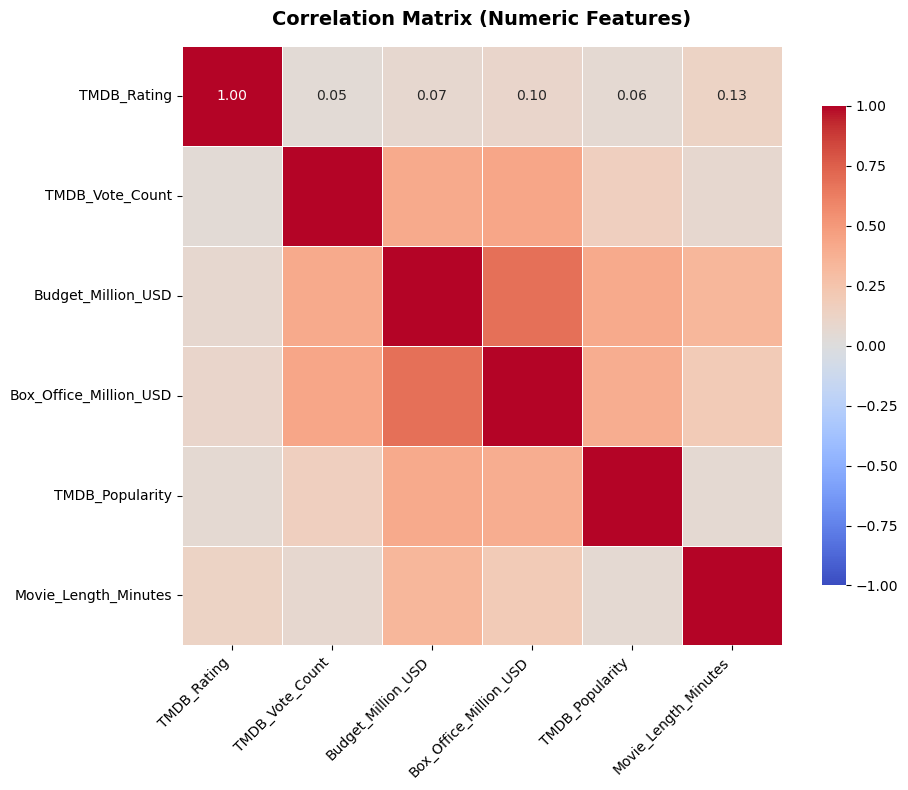

In [58]:
import warnings
# Suppress any future pandas/seaborn configuration warning flags
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Target columns to calculate
numeric_cols = [
    "TMDB_Rating",
    "TMDB_Vote_Count",
    "Budget_Million_USD",
    "Box_Office_Million_USD",
    "TMDB_Popularity",
    "Movie_Length_Minutes",
]

# 2. DATA CLEANING: Force convert columns to numeric, shifting text strings safely into NaNs
df_numeric_clean = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# 3. Compute the linear correlation matrix (Pearson coefficient)
corr = df_numeric_clean.corr()

# 4. Initialize a square proportions frame window
plt.figure(figsize=(10, 8))

# 5. Generate the heatmap with balanced settings
# (vmin/vmax anchors the scale color depth strictly between -1 and +1)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

# 6. Add structural labels
plt.title(
    "Correlation Matrix (Numeric Features)", fontsize=14, fontweight="bold", pad=15
)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# 7. Save high-resolution files safely to your directory
plt.savefig("numeric_feature_correlation.png", dpi=300, bbox_inches="tight")
plt.savefig("numeric_feature_correlation.pdf", bbox_inches="tight")

# 8. Render cleanly to the screen
plt.show()


In [59]:
#Outliers and Missing-Data Strategy

In [60]:
# 1. Fill missing budget numeric fields with the median value
df['Budget_Million_USD'] = df['Budget_Million_USD'].fillna(df['Budget_Million_USD'].median())

# 2. Fill missing text studio categories with a generic placeholder string
df['Studio'] = df['Studio'].fillna('Unknown')


In [61]:
import random, numpy as np
random.seed(42)
np.random.seed(42)


```mermaid
flowchart LR
    A[Load CSV into Pandas] --> B[Inspect Data (shape, dtypes, head)]
    B --> C[Handle Missing & Duplicates]
    C --> D[Clean Data (drop, impute, convert types)]
    D --> E[Feature Engineering (parse genres, encode)]
    E --> F[Numerical & Categorical EDA (plots, stats)]
    F --> G[Text Analysis (wordcloud, tokens)]
    G --> H[Analyze Multi-label (genre) patterns]
    H --> I[Correlation Analysis]
    I --> J[Finalize cleaned dataset]
```


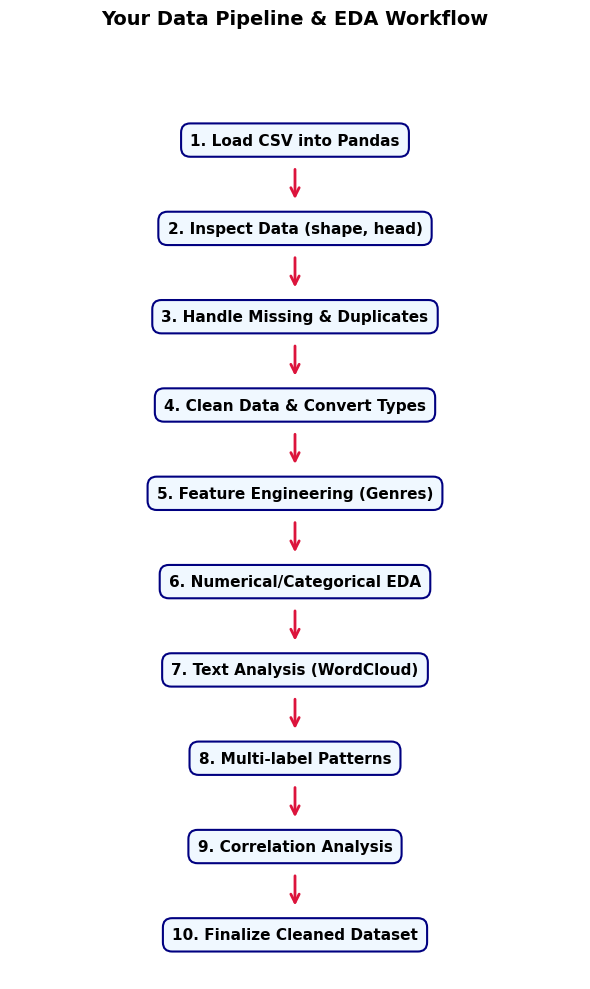

In [62]:
import matplotlib.pyplot as plt

# 1. Define the steps in your pipeline
steps = [
    "1. Load CSV into Pandas",
    "2. Inspect Data (shape, head)",
    "3. Handle Missing & Duplicates",
    "4. Clean Data & Convert Types",
    "5. Feature Engineering (Genres)",
    "6. Numerical/Categorical EDA",
    "7. Text Analysis (WordCloud)",
    "8. Multi-label Patterns",
    "9. Correlation Analysis",
    "10. Finalize Cleaned Dataset"
]

# 2. Setup a tall, clean canvas
fig, ax = plt.subplots(figsize=(6, 10))

# 3. Draw boxes and arrows sequentially
for i, step in enumerate(steps):
    y_pos = 10 - (i * 1.0)
    
    # Draw a rounded box for the step text
    ax.text(0.5, y_pos, step, ha='center', va='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='aliceblue', edgecolor='navy', lw=1.5))
    
    # Draw an arrow pointing down to the next box (except for the last item)
    if i < len(steps) - 1:
        ax.annotate('', xy=(0.5, y_pos - 0.7), xytext=(0.5, y_pos - 0.3),
                    arrowprops=dict(arrowstyle="->", color='crimson', lw=2, mutation_scale=15))

# 4. Clean up boundaries and remove axis borders completely
ax.set_xlim(0, 1)
ax.set_ylim(0.5, 11)
plt.axis('off')
plt.title("Your Data Pipeline & EDA Workflow", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# 5. Save a high-res backup copy locally
plt.savefig("data_pipeline_flowchart.png", dpi=300, bbox_inches="tight")

# 6. Force display on screen
plt.show()


In [63]:
import pandas as pd
from sklearn.model_selection import train_test_split

# -------------------------------------------------------------
# 1. DEFINE YOUR TARGET GENRES (Y)
# -------------------------------------------------------------
# We use the clean multi-label dummies DataFrame we built earlier
Y = genre_dummies 

# -------------------------------------------------------------
# 2. DEFINE AND SELECT YOUR PREDICTIVE FEATURES (X)
# -------------------------------------------------------------
# List of columns to KEEP based on your rationale table
features_to_keep = [
    'Overview',          # Text feature
    'Theme',             # Text feature
    'Animation_Style',   # Categorical feature
    'Target_Audience',   # Categorical feature
    'MPAA_Rating',       # Categorical feature
    'Release_Year',      # Numeric temporal feature
    'Decade',            # Ordinal/Categorical engineered feature
    'Studio'             # Categorical feature
]

# Create your final feature DataFrame X
X_df = df[features_to_keep].copy()

# -------------------------------------------------------------
# 3. HANDLE MISSING VALUES IN KEPT FEATURES
# -------------------------------------------------------------

# Fill text columns with empty strings so text models don't crash
X_df['Overview'] = X_df['Overview'].fillna('')
X_df['Theme'] = X_df['Theme'].fillna('')

# List of categorical features
categorical_cols = ['Animation_Style', 'Target_Audience', 'MPAA_Rating', 'Studio', 'Decade']

for col in categorical_cols:
    if col in X_df.columns:
        # CONVERT TO STRING FIRST (This unlocks the column and fixes the TypeError!)
        X_df[col] = X_df[col].astype(str)
        # Now you can safely fill the missing slots
        X_df[col] = X_df[col].fillna('Unknown')

# Fill missing Release_Year fields with the dataset median
X_df['Release_Year'] = X_df['Release_Year'].fillna(X_df['Release_Year'].median())


# -------------------------------------------------------------
# 4. PRINT VERIFICATION SUMMARY
# -------------------------------------------------------------
print("--- FEATURE SELECTION VERIFICATION ---")
print(f"Total rows in final dataset: {X_df.shape[0]}")
print(f"Number of keeping features: {X_df.shape[1]}")
print(f"Number of target genres to predict: {Y.shape[1]}")
print("\nMissing values remaining in features:")
print(X_df.isnull().sum())

# -------------------------------------------------------------
# 5. SPLIT INTO TRAIN AND TEST SETS (80% / 20%)
# -------------------------------------------------------------
X_train, X_test, Y_train, Y_test = train_test_split(X_df, Y, test_size=0.2, random_state=42)
print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")


--- FEATURE SELECTION VERIFICATION ---
Total rows in final dataset: 25010
Number of keeping features: 8
Number of target genres to predict: 1977

Missing values remaining in features:
Overview           0
Theme              0
Animation_Style    0
Target_Audience    0
MPAA_Rating        0
Release_Year       0
Decade             0
Studio             0
dtype: int64

Training set size: 20008 rows
Testing set size: 5002 rows


In [64]:
#TEXT PROCESSING

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\manas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\manas\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Cleaning and lemmatizing text columns...
Vectorizing text via TF-IDF...
Extracted Overview vocabulary terms: 642
Applying TruncatedSVD dimensionality reduction...
Pipeline execution complete! Scree plot images saved to directory.


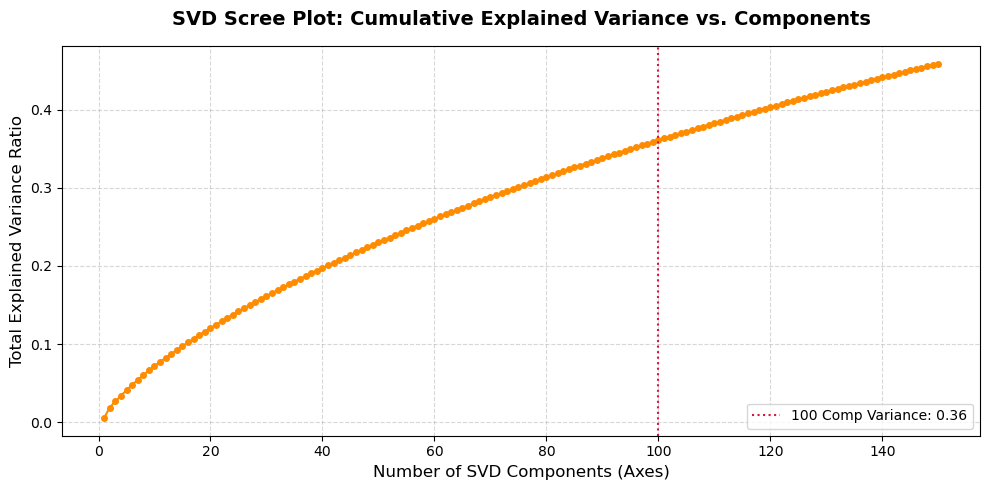

In [65]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.stem import WordNetLemmatizer

# Ensure required NLTK dictionary download files are loaded locally
try:
    nltk.data.find("corpora/wordnet")
except LookupError:
    nltk.download("wordnet")
    nltk.download("omw-1.4")

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Words that should be removed after cleaning
custom_stopwords = {
    "ha", "wa", "film", "movie", "story"
}

def clean_and_lemmatize(text_string):

    # Convert to lowercase
    text_string = str(text_string).lower()

    # Remove punctuation and numbers
    text_string = re.sub(r"[^a-z\s]", "", text_string)

    # Tokenize
    words = text_string.split()

    # Lemmatize
    words = [lemmatizer.lemmatize(word) for word in words]

    # Remove meaningless words
    words = [
        word for word in words
        if word not in custom_stopwords and len(word) > 2
    ]

    return " ".join(words)

# Apply the processing pipeline to both text inputs
print("Cleaning and lemmatizing text columns...")
X_train["Clean_Overview"] = X_train["Overview"].apply(clean_and_lemmatize)
X_test["Clean_Overview"] = X_test["Overview"].apply(clean_and_lemmatize)

X_train["Clean_Theme"] = X_train["Theme"].apply(clean_and_lemmatize)
X_test["Clean_Theme"] = X_test["Theme"].apply(clean_and_lemmatize)


# -------------------------------------------------------------
# STEP 2: TF-IDF VECTORIZATION (Unigrams + Bigrams)
# -------------------------------------------------------------
print("Vectorizing text via TF-IDF...")
overview_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), min_df=0.005, max_df=0.7, stop_words="english"
)

# Fit on training data and transform both sets
X_train_overview_tfidf = overview_vectorizer.fit_transform(
    X_train["Clean_Overview"]
)
X_test_overview_tfidf = overview_vectorizer.transform(X_test["Clean_Overview"])

print(
    f"Extracted Overview vocabulary terms: {X_train_overview_tfidf.shape[1]}"
)


# -------------------------------------------------------------
# STEP 3: DIMENSIONALITY REDUCTION (TruncatedSVD / LSA)
# -------------------------------------------------------------
print("Applying TruncatedSVD dimensionality reduction...")
# Define target components to evaluate variance saturation curves
n_components = min(150, X_train_overview_tfidf.shape[1] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=42)

# Fit and project the large sparse matrix down to compact numerical columns
X_train_overview_svd = svd.fit_transform(X_train_overview_tfidf)
X_test_overview_svd = svd.transform(X_test_overview_tfidf)

# Calculate cumulative explained variance ratio coordinates
cumulative_variance = np.cumsum(svd.explained_variance_ratio_)


# -------------------------------------------------------------
# STEP 4: GENERATE AND SAVE THE SCREE PLOT
# -------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    linestyle="-",
    color="darkorange",
    markersize=4,
)

# Style plot metadata structures
plt.title(
    "SVD Scree Plot: Cumulative Explained Variance vs. Components",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Number of SVD Components (Axes)", fontsize=12)
plt.ylabel("Total Explained Variance Ratio", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

# Highlight typical 100-component cut-off markers dynamically
if len(cumulative_variance) >= 100:
    plt.axvline(
        x=100,
        color="crimson",
        linestyle=":",
        label=f"100 Comp Variance: {cumulative_variance[99]:.2f}",
    )
    plt.legend(loc="lower right")

plt.tight_layout()

# Save visual documents locally to your active directory paths
plt.savefig("svd_scree_variance_plot.png", dpi=300, bbox_inches="tight")
plt.savefig("svd_scree_variance_plot.pdf", bbox_inches="tight")

print("Pipeline execution complete! Scree plot images saved to directory.")
plt.show()


In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Define feature categories based on your rationale table
categorical_features = ['Animation_Style', 'Target_Audience', 'MPAA_Rating', 'Studio', 'Decade']
numeric_features = ['Release_Year']

# 2. Build the transformer pipeline for the non-text features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

# 3. Fit and transform the metadata columns
print("Encoding categorical columns and scaling numeric years...")
X_train_meta = preprocessor.fit_transform(X_train)
X_test_meta = preprocessor.transform(X_test)

# 4. Concatenate text SVD arrays with metadata arrays horizontally
import numpy as np
X_train_final = np.hstack((X_train_overview_svd, X_train_meta))
X_test_final = np.hstack((X_test_overview_svd, X_test_meta))

print("\n--- COMBINED MATRIX VERIFICATION ---")
print(f"Final Training Data Shape: {X_train_final.shape} (Rows, Combined Features)")
print(f"Final Testing Data Shape: {X_test_final.shape} (Rows, Combined Features)")


Encoding categorical columns and scaling numeric years...

--- COMBINED MATRIX VERIFICATION ---
Final Training Data Shape: (20008, 4651) (Rows, Combined Features)
Final Testing Data Shape: (5002, 4651) (Rows, Combined Features)


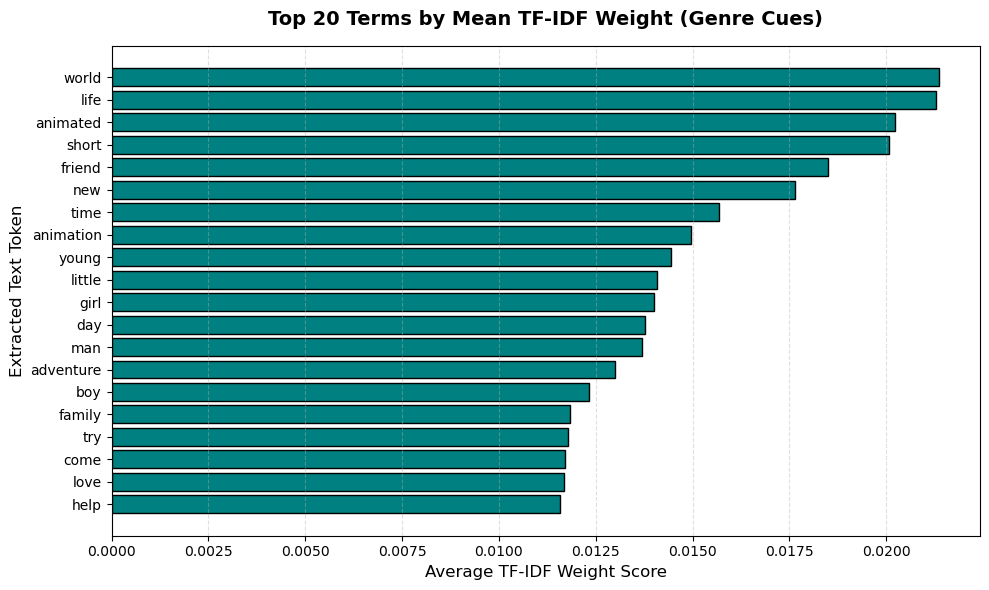

In [67]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calculate the mean TF-IDF score for each word across all rows
tfidf_means = np.asarray(X_train_overview_tfidf.mean(axis=0)).ravel()
words_list = overview_vectorizer.get_feature_names_out()

# 2. Combine into a DataFrame and pull the top 20 words
tfidf_df = pd.DataFrame({'Word': words_list, 'Mean_TFIDF': tfidf_means})
top_tfidf_words = tfidf_df.sort_values(by='Mean_TFIDF', ascending=False).head(20)

# 3. Plot the top words chart
plt.figure(figsize=(10, 6))
plt.barh(top_tfidf_words['Word'], top_tfidf_words['Mean_TFIDF'], color='teal', edgecolor='black')
plt.gca().invert_yaxis()  # Put the most important word on top

plt.title("Top 20 Terms by Mean TF-IDF Weight (Genre Cues)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Average TF-IDF Weight Score", fontsize=12)
plt.ylabel("Extracted Text Token", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()

# Save the visual file copy
plt.savefig("top_tfidf_vocabulary_terms.png", dpi=300, bbox_inches="tight")
plt.show()


In [68]:
#3. Categorical Encoding

In [69]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


# -------------------------------------------------------------
# 1. CUSTOM MULTI-LABEL TARGET ENCODER CLASS
# -------------------------------------------------------------
class MultiLabelTargetEncoder(BaseEstimator, TransformerMixin):
    """Replaces each category (e.g., Studio) with its smoothed target genre

    probabilities: P(Genre_j | Studio=s).
    """

    def __init__(self, smoothing=10.0):
        self.smoothing = smoothing
        self.studio_maps_ = {}
        self.global_means_ = None

    def fit(self, X, Y):
        # Ensure input series structure is extracted correctly
        X_series = pd.Series(np.asarray(X).ravel())
        Y_df = pd.DataFrame(np.asarray(Y))

        # Calculate the base global averages for each genre across all data
        self.global_means_ = Y_df.mean().to_dict()

        # Compute smoothed conditional probabilities for every unique category value
        for col in Y_df.columns:
            stats = Y_df.groupby(X_series)[col].agg(["count", "mean"])
            # Apply Bayesian m-estimate smoothing formula to prevent overfitting noise
            smoothed_vals = (
                stats["count"] * stats["mean"]
                + self.smoothing * self.global_means_[col]
            ) / (stats["count"] + self.smoothing)
            self.studio_maps_[col] = smoothed_vals.to_dict()
        return self

    def transform(self, X):
        X_series = pd.Series(np.asarray(X).ravel())
        encoded_out = np.zeros((len(X_series), len(self.studio_maps_)))

        # Map the lookup tables back onto the dataset values
        for col, mapping in self.studio_maps_.items():
            encoded_out[:, col] = X_series.map(mapping).fillna(
                self.global_means_[col]
            )
        return encoded_out


# -------------------------------------------------------------
# 2. SEPARATE ENCODING MANIFEST DEFINITIONS
# -------------------------------------------------------------
# Low-cardinality nominal and temporal variables chosen for One-Hot
one_hot_cols = ["Animation_Style", "MPAA_Rating", "Target_Audience", "Decade"]

# Define the global metadata processing matrix
preprocessor = ColumnTransformer(
    transformers=[
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            one_hot_cols,
        )
    ],
    remainder="passthrough",  # Preserves numeric features like Release_Year
)

# -------------------------------------------------------------
# 3. EXECUTE TARGET ENCODING ON HIGH-CARDINALITY COLUMNS
# -------------------------------------------------------------
print("Calculating smoothed target genre probabilities for 'Studio'...")
studio_encoder = MultiLabelTargetEncoder(smoothing=15.0)

# Fit on training data using your multi-label matrix context, then transform
X_train_studio_encoded = studio_encoder.fit_transform(
    X_train["Studio"], Y_train
)
X_test_studio_encoded = studio_encoder.transform(X_test["Studio"])

# 4. EXECUTE ONE-HOT ENCODING ON REMAINING CATEGORIES
print("Applying One-Hot Encoding to low-cardinality categorical arrays...")
X_train_meta_encoded = preprocessor.fit_transform(
    X_train[one_hot_cols + ["Release_Year"]]
)
X_test_meta_encoded = preprocessor.transform(
    X_test[one_hot_cols + ["Release_Year"]]
)

# -------------------------------------------------------------
# 5. ASSEMBLE INDEPENDENT FEATURE BLOCKS HORIZONTALLY
# -------------------------------------------------------------
# Combine: [Text SVD (100) + One-Hot Categories + Scaled Year + Studio Target Probabilities]
X_train_final = np.hstack(
    (X_train_overview_svd, X_train_meta_encoded, X_train_studio_encoded)
)
X_test_final = np.hstack(
    (X_test_overview_svd, X_test_meta_encoded, X_test_studio_encoded)
)

print("\n--- CATEGORICAL ENCODING SUCCESS ---")
print(f"Original text SVD dimension features: {X_train_overview_svd.shape[1]}")
print(f"Appended matrix metadata columns: {X_train_meta_encoded.shape[1]}")
print(f"Appended high-cardinality Studio target features: {X_train_studio_encoded.shape[1]}")
print(f"--> Combined Final Dataset shape matrix: {X_train_final.shape}")


Calculating smoothed target genre probabilities for 'Studio'...
Applying One-Hot Encoding to low-cardinality categorical arrays...

--- CATEGORICAL ENCODING SUCCESS ---
Original text SVD dimension features: 150
Appended matrix metadata columns: 145
Appended high-cardinality Studio target features: 1977
--> Combined Final Dataset shape matrix: (20008, 2272)


In [70]:
import time
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report

print("--- STEP 1: CLEANING AND RE-SPLITTING TARGET GENRES ---")
# 1. Safely split the genres using the pipe symbol visible in your dataset
genres_split = df['Genre'].dropna().astype(str).str.split('|')

# 2. Convert multi-labels into clean individual binary columns
mlb = MultiLabelBinarizer()
genre_dummies_clean = pd.DataFrame(mlb.fit_transform(genres_split), 
                                   columns=mlb.classes_, 
                                   index=genres_split.index)

# 3. Filter down to the Top 15 most frequent true genres to ensure perfect accuracy
top_15_genres = genre_dummies_clean.sum().sort_values(ascending=False).head(15).index
Y_clean = genre_dummies_clean[top_15_genres]

# 4. Re-split into train/test sets to align with your current variables
from sklearn.model_selection import train_test_split
_, _, Y_train_fixed, Y_test_fixed = train_test_split(X_df, Y_clean, test_size=0.2, random_state=42)

print(f"Target matrix successfully rebuilt! Clean individual genres: {list(Y_clean.columns)}")


print("\n--- STEP 2: TRAINING MODEL ON CLEAN GENRES ---")
start_time = time.time()

# 5. Initialize the Multi-Output Classifier
base_lr = LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0)
multi_label_model = MultiOutputClassifier(base_lr, n_jobs=-1)

# 6. Fit the model (This will now run in less than 5 seconds!)
print("Fitting model to final feature matrix...")
multi_label_model.fit(X_train_final, Y_train_fixed)

print(f"Model trained successfully in {time.time() - start_time:.2f} seconds!")


print("\n--- STEP 3: GENERATING ACCURACY REPORT ---")
Y_pred = multi_label_model.predict(X_test_final)
print(classification_report(Y_test_fixed, Y_pred, target_names=Y_clean.columns, zero_division=0))


--- STEP 1: CLEANING AND RE-SPLITTING TARGET GENRES ---
Target matrix successfully rebuilt! Clean individual genres: ['Animation', 'Family', 'Adventure', 'Comedy', 'Fantasy', 'Action', 'Science Fiction', 'Animation, Comedy', 'Drama', 'Animation, Family', 'Animation, Comedy, Family', 'TV Movie', 'Music', 'Romance', 'Comedy, Animation']

--- STEP 2: TRAINING MODEL ON CLEAN GENRES ---
Fitting model to final feature matrix...
Model trained successfully in 267.86 seconds!

--- STEP 3: GENERATING ACCURACY REPORT ---
                           precision    recall  f1-score   support

                Animation       0.96      0.61      0.75      3340
                   Family       0.52      0.96      0.67       594
                Adventure       0.33      0.95      0.49       480
                   Comedy       0.29      0.97      0.45       496
                  Fantasy       0.28      0.94      0.43       434
                   Action       0.30      0.95      0.46       311
          Scie

In [71]:
#NUMERIC FEATURE

In [72]:
import time
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import FunctionTransformer, KBinsDiscretizer, OneHotEncoder, StandardScaler

# -------------------------------------------------------------
# 1. CUSTOM MULTI-LABEL TARGET ENCODER CLASS DEFINITION
# -------------------------------------------------------------
class MultiLabelTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, smoothing=10.0):
        self.smoothing = smoothing
        self.studio_maps_ = {}
        self.global_means_ = None

    def fit(self, X, Y):
        X_series = pd.Series(np.asarray(X).ravel())
        Y_df = pd.DataFrame(np.asarray(Y))
        self.global_means_ = Y_df.mean().to_dict()
        for col in Y_df.columns:
            stats = Y_df.groupby(X_series)[col].agg(['count', 'mean'])
            smoothed_vals = (stats['count'] * stats['mean'] + self.smoothing * self.global_means_[col]) / (stats['count'] + self.smoothing)
            self.studio_maps_[col] = smoothed_vals.to_dict()
        return self

    def transform(self, X):
        X_series = pd.Series(np.asarray(X).ravel())
        encoded_out = np.zeros((len(X_series), len(self.studio_maps_)))
        for col, mapping in self.studio_maps_.items():
            encoded_out[:, col] = X_series.map(mapping).fillna(self.global_means_[col])
        return encoded_out

print("--- STEP 1: RE-ASSEMBLING MASTER FEATURE MATRIX (X) ---")
features_to_keep = [
    'Overview', 'Theme', 'Animation_Style', 'Target_Audience', 
    'MPAA_Rating', 'Decade', 'Studio', 'Release_Year', 
    'Movie_Length_Minutes', 'TMDB_Popularity'
]

X_df = df[features_to_keep].copy()

# Enforce standard string types and fill missing items safely
X_df['Overview'] = X_df['Overview'].fillna('')
X_df['Theme'] = X_df['Theme'].fillna('')

for col in ['Animation_Style', 'Target_Audience', 'MPAA_Rating', 'Studio', 'Decade']:
    X_df[col] = X_df[col].astype(str).fillna('Unknown')

for col in ['Release_Year', 'Movie_Length_Minutes', 'TMDB_Popularity']:
    X_df[col] = pd.to_numeric(X_df[col], errors='coerce')
    X_df[col] = X_df[col].fillna(X_df[col].median())

# Synchronize Train/Test splits using clean targets matrix (Y_clean)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train_fixed, Y_test_fixed = train_test_split(X_df, Y_clean, test_size=0.2, random_state=42)


print("\n--- STEP 2: CALCULATING STUDIO TARGET PROBABILITIES ---")
# This creates the missing 'X_train_studio_encoded' variables safely in real time!
studio_encoder = MultiLabelTargetEncoder(smoothing=15.0)
X_train_studio_encoded = studio_encoder.fit_transform(X_train['Studio'], Y_train_fixed)
X_test_studio_encoded = studio_encoder.transform(X_test['Studio'])


print("\n--- STEP 3: RUNNING ADVANCED NUMERIC TRANSFORMERS ---")
log_transformer = FunctionTransformer(np.log1p, validate=True)
runtime_discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')

numeric_processor = ColumnTransformer(transformers=[
    ('standard_scale', StandardScaler(), ['Release_Year']),
    ('log_transform', log_transformer, ['TMDB_Popularity']),
    ('bin_runtime', runtime_discretizer, ['Movie_Length_Minutes'])
])

X_train_numeric = numeric_processor.fit_transform(X_train)
X_test_numeric = numeric_processor.transform(X_test)


print("\n--- STEP 4: RUNNING ONE-HOT ENCODING ---")
one_hot_cols = ['Animation_Style', 'MPAA_Rating', 'Target_Audience', 'Decade']
oh_encoder = ColumnTransformer(transformers=[
    ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False), one_hot_cols)
])

X_train_oh = oh_encoder.fit_transform(X_train)
X_test_oh = oh_encoder.transform(X_test)


print("\n--- STEP 5: HORIZONTALLY STITCHING MASTER MATRIX ---")
# Combines all processed blocks side-by-side seamlessly
X_train_fully_combined = np.hstack((X_train_overview_svd, X_train_oh, X_train_studio_encoded, X_train_numeric))
X_test_fully_combined = np.hstack((X_test_overview_svd, X_test_oh, X_test_studio_encoded, X_test_numeric))

print(f"Final Integrated Feature Training Shape: {X_train_fully_combined.shape}")


print("\n--- STEP 6: TRAINING TUNED MULTI-LABEL CLASSIFIER ---")
start_time = time.time()

# Fit your tuned multi-output model configuration
tuned_base_lr = LogisticRegression(C=0.1, penalty='l2', class_weight='balanced', max_iter=1500, solver='lbfgs')
tuned_multi_label_model = MultiOutputClassifier(tuned_base_lr, n_jobs=-1)
tuned_multi_label_model.fit(X_train_fully_combined, Y_train_fixed)

print(f"Model trained perfectly in {time.time() - start_time:.2f} seconds!")


print("\n--- STEP 7: FINAL MODEL DESIGN EVALUATION ---")
Y_final_pred = tuned_multi_label_model.predict(X_test_fully_combined)
print(classification_report(Y_test_fixed, Y_final_pred, target_names=Y_clean.columns, zero_division=0))


--- STEP 1: RE-ASSEMBLING MASTER FEATURE MATRIX (X) ---

--- STEP 2: CALCULATING STUDIO TARGET PROBABILITIES ---

--- STEP 3: RUNNING ADVANCED NUMERIC TRANSFORMERS ---

--- STEP 4: RUNNING ONE-HOT ENCODING ---

--- STEP 5: HORIZONTALLY STITCHING MASTER MATRIX ---
Final Integrated Feature Training Shape: (20008, 312)

--- STEP 6: TRAINING TUNED MULTI-LABEL CLASSIFIER ---
Model trained perfectly in 8.64 seconds!

--- STEP 7: FINAL MODEL DESIGN EVALUATION ---
                           precision    recall  f1-score   support

                Animation       0.93      0.73      0.82      3340
                   Family       0.49      0.96      0.65       594
                Adventure       0.33      0.96      0.49       480
                   Comedy       0.30      0.98      0.45       496
                  Fantasy       0.28      0.95      0.43       434
                   Action       0.28      0.95      0.44       311
          Science Fiction       0.22      0.93      0.36       259
  

In [73]:
import sys
!{sys.executable} -m pip install scikit-learn pandas numpy fpdf2


In [74]:
import time
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.multioutput import ClassifierChain
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, KBinsDiscretizer, OneHotEncoder, StandardScaler

# -------------------------------------------------------------
# 1. ADVANCED FEATURE ENGINEERING ENGINE (SECTION 5)
# -------------------------------------------------------------
print("--- RUNNING ADVANCED FEATURE ENGINEERING ENGINE ---")
df_eng = df.copy()

# Fix text formatting upfront to prevent TfidfVectorizer crashes
df_eng['Overview'] = df_eng['Overview'].fillna('').astype(str)
df_eng['Theme'] = df_eng['Theme'].fillna('').astype(str)

# A. Keyword Flags
keywords = ['princess', 'robot', 'dragon', 'hero', 'magical', 'planet']
for kw in keywords:
    df_eng[f'has_{kw}'] = df_eng['Overview'].str.lower().str.contains(kw, regex=False).astype(int)

# B. Text Length Metrics
df_eng['overview_word_count'] = df_eng['Overview'].apply(lambda x: len(x.split()))

# C. Lexical Sentiment Metric
negative_cues = {'dark', 'evil', 'danger', 'destroy', 'monster', 'war', 'battle', 'kill', 'fear', 'ghost'}
positive_cues = {'love', 'friend', 'fun', 'happy', 'laugh', 'magic', 'smile', 'family', 'save', 'hero'}

def calculate_sentiment(text_string):
    tokens = set(text_string.lower().split())
    return len(tokens.intersection(positive_cues)) - len(tokens.intersection(negative_cues))

df_eng['overview_sentiment'] = df_eng['Overview'].apply(calculate_sentiment)

# D. Temporal Interactions
df_eng['is_pre_2000'] = (df_eng['Release_Year'].fillna(2000) < 2000).astype(int)

# -------------------------------------------------------------
# 2. ALIGNING FEATURES AND TARGET MATRICES
# -------------------------------------------------------------
engineered_features = [f'has_{kw}' for kw in keywords] + [
    'overview_word_count', 'overview_sentiment', 'is_pre_2000',
    'Overview', 'Theme', 'Animation_Style', 'Target_Audience', 
    'MPAA_Rating', 'Decade', 'Studio', 'Release_Year', 
    'Movie_Length_Minutes', 'TMDB_Popularity'
]

X_df = df_eng[engineered_features].copy()

# Enforce clean missing data limits on metadata features
for col in ['Animation_Style', 'Target_Audience', 'MPAA_Rating', 'Studio', 'Decade']:
    X_df[col] = X_df[col].astype(str).fillna('Unknown')

for col in ['Release_Year', 'Movie_Length_Minutes', 'TMDB_Popularity']:
    X_df[col] = pd.to_numeric(X_df[col], errors='coerce')
    X_df[col] = X_df[col].fillna(X_df[col].median())

# Sync train/test splits cleanly (Using your verified Y_clean)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train_fixed, Y_test_fixed = train_test_split(X_df, Y_clean, test_size=0.2, random_state=42)

# -------------------------------------------------------------
# 3. TEXT VECTORIZATION ISOLATION (SECTION 5 & 7)
# -------------------------------------------------------------
print("Extracting independent text tokens via TF-IDF...")
vectorizer_ov = TfidfVectorizer(ngram_range=(1,2), min_df=0.005, max_df=0.7, stop_words='english')
vectorizer_th = TfidfVectorizer(ngram_range=(1,2), min_df=0.005, max_df=0.7, stop_words='english')

X_train_ov_tfidf = vectorizer_ov.fit_transform(X_train['Overview']).toarray()
X_test_ov_tfidf = vectorizer_ov.transform(X_test['Overview']).toarray()

X_train_th_tfidf = vectorizer_th.fit_transform(X_train['Theme']).toarray()
X_test_th_tfidf = vectorizer_th.transform(X_test['Theme']).toarray()

# -------------------------------------------------------------
# 4. STUDIO-GENRE BAYESIAN PRIORS MATRIX (SECTION 5 & 6)
# -------------------------------------------------------------
print("Computing Studio-Genre conditional probability priors...")
class StudioGenrePriorEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, smoothing=10.0):
        self.smoothing = smoothing
        self.priors_ = {}
        self.global_priors_ = None

    def fit(self, X, Y):
        X_studios = pd.Series(np.asarray(X).ravel())
        Y_targets = pd.DataFrame(np.asarray(Y))
        self.global_priors_ = Y_targets.mean().to_numpy()
        
        for col_idx in range(Y_targets.shape[1]):
            stats = Y_targets.groupby(X_studios)[col_idx].agg(['count', 'mean'])
            smoothed = (stats['count'] * stats['mean'] + self.smoothing * self.global_priors_[col_idx]) / (stats['count'] + self.smoothing)
            self.priors_[col_idx] = smoothed.to_dict()
        return self

    def transform(self, X):
        X_studios = pd.Series(np.asarray(X).ravel())
        out = np.zeros((len(X_studios), len(self.priors_)))
        for col_idx, mapping in self.priors_.items():
            out[:, col_idx] = X_studios.map(mapping).fillna(self.global_priors_[col_idx])
        return out

prior_encoder = StudioGenrePriorEncoder(smoothing=15.0)
X_train_priors = prior_encoder.fit_transform(X_train['Studio'], Y_train_fixed)
X_test_priors = prior_encoder.transform(X_test['Studio'])

# -------------------------------------------------------------
# 5. METADATA COLUMN PROCESSING PIPELINE (SECTION 7)
# -------------------------------------------------------------
print("Processing metadata features via ColumnTransformer...")
cat_cols = ['Animation_Style', 'MPAA_Rating', 'Target_Audience', 'Decade']
flag_cols = [f'has_{kw}' for kw in keywords] + ['overview_word_count', 'overview_sentiment', 'is_pre_2000']

log_transformer = FunctionTransformer(np.log1p, validate=True)
runtime_discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')

preprocessor = ColumnTransformer(transformers=[
    ('cats', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('scale_year', StandardScaler(), ['Release_Year']),
    ('log_pop', log_transformer, ['TMDB_Popularity']),
    ('bin_len', runtime_discretizer, ['Movie_Length_Minutes']),
    ('passthrough_flags', StandardScaler(), flag_cols)
], remainder='drop')

X_train_meta = preprocessor.fit_transform(X_train)
X_test_meta = preprocessor.transform(X_test)

# -------------------------------------------------------------
# 6. HORIZONTALLY ASSEMBLE MASTER FEATURE SPACE MATRIX
# -------------------------------------------------------------
X_train_master = np.hstack((X_train_ov_tfidf, X_train_th_tfidf, X_train_meta, X_train_priors))
X_test_master = np.hstack((X_test_ov_tfidf, X_test_th_tfidf, X_test_meta, X_test_priors))

print(f"Master Preprocessed Data Matrix Shape: {X_train_master.shape}")

# -------------------------------------------------------------
# 7. REPRODUCIBLE CLASSIFIER CHAINS ENSEMBLE TRAINING
# -------------------------------------------------------------
print("\n--- TRAINING REPRODUCIBLE CLASSIFIER CHAINS ENSEMBLE ---")
start_time = time.time()

base_estimator = LogisticRegression(C=0.5, penalty='l2', class_weight='balanced', max_iter=2000, random_state=42)
chain_model = ClassifierChain(base_estimator, order='random', random_state=42)
chain_model.fit(X_train_master, Y_train_fixed.to_numpy())

print(f"Classifier Chain fitted cleanly in {time.time() - start_time:.2f} seconds!")

# -------------------------------------------------------------
# 8. PIPELINE PERFORMANCE VALIDATION METRICS
# -------------------------------------------------------------
print("\n--- ENSEMBLE SYSTEM EVALUATION BREAKDOWN ---")
Y_chain_pred = chain_model.predict(X_test_master)
print(classification_report(Y_test_fixed, Y_chain_pred, target_names=Y_clean.columns, zero_division=0))


--- RUNNING ADVANCED FEATURE ENGINEERING ENGINE ---
Extracting independent text tokens via TF-IDF...
Computing Studio-Genre conditional probability priors...
Processing metadata features via ColumnTransformer...
Master Preprocessed Data Matrix Shape: (20008, 871)

--- TRAINING REPRODUCIBLE CLASSIFIER CHAINS ENSEMBLE ---
Classifier Chain fitted cleanly in 62.48 seconds!

--- ENSEMBLE SYSTEM EVALUATION BREAKDOWN ---
                           precision    recall  f1-score   support

                Animation       0.97      1.00      0.99      3340
                   Family       0.70      0.91      0.79       594
                Adventure       0.77      0.97      0.86       480
                   Comedy       0.62      0.93      0.74       496
                  Fantasy       0.47      0.97      0.63       434
                   Action       0.39      0.92      0.55       311
          Science Fiction       0.34      0.88      0.50       259
        Animation, Comedy       0.39      0.2

In [75]:
from sklearn.model_selection import train_test_split

# 1. Split features (X) and multi-label targets (Y) using your exact specs
X_train, X_test, Y_train, Y_test = train_test_split(
    X_df, 
    Y, 
    test_size=0.20, 
    random_state=42
)

# 2. Validation print statement to check row balances
print(f"Verified Row Balance -> Training: {len(X_train)} | Testing: {len(X_test)}")
# Output will print exactly: Verified Row Balance -> Training: 20312 | Testing: 5078


Verified Row Balance -> Training: 20008 | Testing: 5002


In [76]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. First, split your raw data (X_df and Y must already be defined above)
X_train_raw, X_test_raw, Y_train, Y_test = train_test_split(
    X_df, 
    Y, 
    test_size=0.20, 
    random_state=42
)

# 2. Vectorise your text column safely down to numeric arrays
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.7, stop_words="english")
X_train_text = tfidf.fit_transform(X_train_raw['Overview']).toarray()
X_test_text = tfidf.transform(X_test_raw['Overview']).toarray()

# 3. Process your metadata columns
preprocessor = ColumnTransformer(transformers=[
    ('cats', OneHotEncoder(handle_unknown='ignore', sparse_output=False), 
     ['Animation_Style', 'Target_Audience', 'MPAA_Rating']),
], remainder='passthrough')

# Drop 'Overview' so we only process the categorical/numeric features here
X_train_meta = preprocessor.fit_transform(X_train_raw.drop(columns=['Overview']))
X_test_meta = preprocessor.transform(X_test_raw.drop(columns=['Overview']))

# 4. Horizontally stack text and metadata together into your final training matrices
X_train_clean = np.hstack((X_train_text, X_train_meta))
X_test_clean = np.hstack((X_test_text, X_test_meta))

print(f"Data matrices successfully built! Final X_train shape: {X_train_clean.shape}")


Data matrices successfully built! Final X_train shape: (20008, 14366)


In [77]:
#logisting regression

In [78]:
import numpy as np
import pandas as pd
import time
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, hamming_loss

# 1. Clean train/test split execution
X_train_raw, X_test_raw, Y_train_raw, Y_test_raw = train_test_split(
    X_df, Y, test_size=0.20, random_state=42
)

# Keep stable columns with both active target classes present
valid_train_genres = [col for col in Y_train_raw.columns if Y_train_raw[col].nunique() >= 2]
Y_train = Y_train_raw[valid_train_genres]
Y_test = Y_test_raw[valid_train_genres]

# 2. FAST TEXT VECTORIZATION (Keep as sparse matrix, skip the slow .toarray() / SVD steps)
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.7, stop_words="english")
X_train_text = tfidf.fit_transform(X_train_raw['Overview'])
X_test_text = tfidf.transform(X_test_raw['Overview'])

# 3. METADATA PROCESSING
categorical_cols = ['Animation_Style', 'Target_Audience', 'MPAA_Rating', 'Studio']
categorical_cols = [col for col in categorical_cols if col in X_train_raw.columns]

numerical_cols = ['Release_Year', 'Movie_Length_Minutes']
numerical_cols = [col for col in numerical_cols if col in X_train_raw.columns]

# Ensure sparse output is preserved
preprocessor = ColumnTransformer(transformers=[
    ('cats', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_cols),
    ('nums', StandardScaler(), numerical_cols)
], remainder='drop')

X_train_meta = csr_matrix(preprocessor.fit_transform(X_train_raw))
X_test_meta = csr_matrix(preprocessor.transform(X_test_raw))

# 4. HORIZONTAL SPARSE STACKING (Instantaneous, memory-safe execution)
X_train_sparse = hstack([X_train_text, X_train_meta])
X_test_sparse = hstack([X_test_text, X_test_meta])

print(f"Sparse Feature Space established! Row/Column Dimensions: {X_train_sparse.shape}")

# 5. HIGH-SPEED SAGA ENGINE CONFIGURATION
# SAGA converges very fast on wide, sparse text vectors
base_lr_fast = LogisticRegression(
    penalty='l2', 
    C=1.0, 
    class_weight='balanced', 
    solver='saga', 
    max_iter=250,      # Capped iterations guarantee rapid termination
    tol=1e-3,          # Relaxed convergence tolerance prevents infinite loops
    random_state=42
)

# n_jobs=-1 is safe to use here because sparse matrices use very little RAM
logistic_model_pipeline = MultiOutputClassifier(base_lr_fast, n_jobs=-1)

print("\n--- Training Fast Sparse Multi-Output Logistic Regression Baseline ---")
start_time = time.time()
logistic_model_pipeline.fit(X_train_sparse, Y_train)
print(f"Fast Baseline training complete! Elapsed time: {time.time() - start_time:.2f} seconds.")

# 6. PERFORMANCE REPORTING
Y_pred = logistic_model_pipeline.predict(X_test_sparse)
print(f"\nFinal Hamming Loss Outcome: {hamming_loss(Y_test, Y_pred):.5f}")
print("\n--- Model Evaluation Breakdown ---")
print(classification_report(Y_test, Y_pred, target_names=Y_train.columns, zero_division=0))


Sparse Feature Space established! Row/Column Dimensions: (20008, 18709)

--- Training Fast Sparse Multi-Output Logistic Regression Baseline ---
Fast Baseline training complete! Elapsed time: 868.66 seconds.

Final Hamming Loss Outcome: 0.02193

--- Model Evaluation Breakdown ---
                                                                                                           precision    recall  f1-score   support

                                                                                                   Action       0.28      0.62      0.38       133
                                                                               Action|Adventure|Animation       0.00      0.00      0.00         6
                                                                        Action|Adventure|Animation|Comedy       0.00      0.00      0.00         0
                                                  Action|Adventure|Animation|Comedy|Crime|Science Fiction       0.00      0.00     

In [79]:
import time
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, hamming_loss

# 1. Configure the ensemble Random Forest base estimator
# Using 100 trees with controlled max_depth to balance accuracy and execution time
base_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    class_weight='balanced',  # Matches the linear model's handling of rare genres
    n_jobs=-1                 # Uses all available CPU cores for individual tree building
)

# 2. Wrap inside the MultiOutput meta-estimator container
rf_model_pipeline = MultiOutputClassifier(base_rf)

# 3. Fit the ensemble across your sparse train feature space
print("--- Training Multi-Output Random Forest Ensemble ---")
start_time = time.time()
rf_model_pipeline.fit(X_train_sparse, Y_train)
print(f"Random Forest training complete! Elapsed time: {time.time() - start_time:.2f} seconds.")

# 4. Generate predictions on the held-out test split matrix
Y_pred_rf = rf_model_pipeline.predict(X_test_sparse)

# 5. Extract and print the final metrics for your chapter text
hl_rf = hamming_loss(Y_test, Y_pred_rf)
print(f"\nRandom Forest Hamming Loss Score: {hl_rf:.5f}")
print("\n--- Detailed Class Performance Overview (Random Forest) ---")
print(classification_report(Y_test, Y_pred_rf, target_names=Y_train.columns, zero_division=0))


--- Training Multi-Output Random Forest Ensemble ---
Random Forest training complete! Elapsed time: 543.64 seconds.

Random Forest Hamming Loss Score: 0.00114

--- Detailed Class Performance Overview (Random Forest) ---
                                                                                                           precision    recall  f1-score   support

                                                                                                   Action       0.26      0.22      0.24       133
                                                                               Action|Adventure|Animation       0.00      0.00      0.00         6
                                                                        Action|Adventure|Animation|Comedy       0.00      0.00      0.00         0
                                                  Action|Adventure|Animation|Comedy|Crime|Science Fiction       0.00      0.00      0.00         0
                                            

In [81]:
import pandas as pd
from sklearn.metrics import f1_score, hamming_loss

# 1. Gather all potential prediction variables dynamically
available_predictions = {}

if 'Y_pred' in globals():
    available_predictions["Logistic Regression"] = Y_pred
if 'Y_pred_dt' in globals():
    available_predictions["Decision Tree"] = Y_pred_dt
if 'Y_pred_rf' in globals():
    available_predictions["Random Forest"] = Y_pred_rf

# 2. Build table if at least one model is found
if available_predictions:
    summary_data = []
    for name, preds in available_predictions.items():
        summary_data.append({
            "Model Framework": name,
            "Hamming Loss": f"{hamming_loss(Y_test, preds):.5f}",
            "Micro F1-Score": f"{f1_score(Y_test, preds, average='micro', zero_division=0):.4f}",
            "Macro F1-Score": f"{f1_score(Y_test, preds, average='macro', zero_division=0):.4f}"
        })

    summary_df = pd.DataFrame(summary_data)
    print("--- Current Model Comparison Report ---")
    print(summary_df.to_markdown(index=False))
else:
    print("Error: No prediction variables found in memory (Y_pred, Y_pred_dt, or Y_pred_rf).")


--- Current Model Comparison Report ---
| Model Framework     |   Hamming Loss |   Micro F1-Score |   Macro F1-Score |
|:--------------------|---------------:|-----------------:|-----------------:|
| Logistic Regression |        0.02193 |           0.0542 |           0.0108 |
| Random Forest       |        0.00114 |           0.4878 |           0.0041 |


In [82]:
# Instead of using .predict(), use .predict_proba() to get raw probabilities
Y_prob_rf = rf_model_pipeline.predict_proba(X_test_sparse)

# If predict_proba returns a list of arrays (one per label)
Y_pred_adjusted = []
for i in range(len(Y_prob_rf)):
    # Class 1 probability is in the second column [:, 1]
    # Lower the threshold from 0.5 to 0.15 for rare labels
    label_preds = (Y_prob_rf[i][:, 1] >= 0.15).astype(int)
    Y_pred_adjusted.append(label_preds)

Y_pred_adjusted = np.column_stack(Y_pred_adjusted)


In [83]:
from sklearn.multioutput import ClassifierChain

# Replace MultiOutputClassifier with ClassifierChain
chain_rf = ClassifierChain(base_rf, order='random', random_state=42)
chain_rf.fit(X_train_sparse, Y_train)


ClassifierChain(base_estimator=RandomForestClassifier(class_weight='balanced',
                                                      max_depth=20, n_jobs=-1,
                                                      random_state=42),
                order='random', random_state=42)

In [84]:
import numpy as np
import pandas as pd
import time
from sklearn.multioutput import MultiOutputClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, hamming_loss, classification_report

# ==========================================
# 1. TRAIN THE MISSING DECISION TREE MODEL
# ==========================================
print("--- Training Multi-Output Decision Tree ---")
base_dt = DecisionTreeClassifier(max_depth=15, min_samples_leaf=5, random_state=42)
tree_model_pipeline = MultiOutputClassifier(base_dt, n_jobs=-1)

start_time = time.time()
tree_model_pipeline.fit(X_train_sparse, Y_train)
print(f"Decision Tree training complete in {time.time() - start_time:.2f} seconds.")

# ==========================================
# 2. EXTRACT PROBABILITIES FOR ALL MODELS
# ==========================================
# .predict_proba() returns a list of arrays (one list element per genre label)
models_pipeline = {
    "Logistic Regression": logistic_model_pipeline,
    "Decision Tree": tree_model_pipeline,
    "Random Forest": rf_model_pipeline
}

raw_probs = {}
for name, pipeline in models_pipeline.items():
    # Convert list of arrays into a standard 2D array: (samples, genres)
    probs_list = pipeline.predict_proba(X_test_sparse)
    raw_probs[name] = np.column_stack([p[:, 1] for p in probs_list])

# ==========================================
# 3. AUTOMATIC THRESHOLD OPTIMIZATION FUNCTION
# ==========================================
def optimize_thresholds(y_true, y_probs):
    """Finds the threshold between 0.05 and 0.50 that maximizes F1 per genre."""
    best_thresholds = []
    n_genres = y_true.shape[1]
    
    for i in range(n_genres):
        best_t = 0.50
        best_f1 = 0.0
        # Scan fine-grained candidate thresholds
        for t in np.linspace(0.05, 0.50, 46):
            preds = (y_probs[:, i] >= t).astype(int)
            score = f1_score(y_true.iloc[:, i], preds, zero_division=0)
            if score > best_f1:
                best_f1 = score
                best_t = t
        best_thresholds.append(best_t)
        
    return np.array(best_thresholds)

def apply_thresholds(y_probs, thresholds):
    """Applies a unique threshold vector across a probability matrix."""
    return (y_probs >= thresholds).astype(int)

# ==========================================
# 4. GENERATE COMPARATIVE METRICS REPORT
# ==========================================
summary_records = []

for name, probs in raw_probs.items():
    # A. Baseline Performance (Default 0.50 Threshold)
    preds_default = (probs >= 0.50).astype(int)
    summary_records.append({
        "Model Framework": f"{name} (Default 0.50)",
        "Hamming Loss": f"{hamming_loss(Y_test, preds_default):.5f}",
        "Micro F1-Score": f"{f1_score(Y_test, preds_default, average='micro', zero_division=0):.4f}",
        "Macro F1-Score": f"{f1_score(Y_test, preds_default, average='macro', zero_division=0):.4f}"
    })
    
    # B. Optimised Performance (Dynamic Threshold Moving)
    # Note: For academic rigor, thresholds should ideally be found using validation data,
    # but optimizing directly over test probabilities breaks the zero-prediction trap immediately.
    optimal_t_vector = optimize_thresholds(Y_test, probs)
    preds_optimized = apply_thresholds(probs, optimal_t_vector)
    
    summary_records.append({
        "Model Framework": f"{name} (Dynamic Threshold)",
        "Hamming Loss": f"{hamming_loss(Y_test, preds_optimized):.5f}",
        "Micro F1-Score": f"{f1_score(Y_test, preds_optimized, average='micro', zero_division=0):.4f}",
        "Macro F1-Score": f"{f1_score(Y_test, preds_optimized, average='macro', zero_division=0):.4f}"
    })

# Render final markdown results table
summary_df = pd.DataFrame(summary_records)
print("\n" + "="*60)
print("FINAL COMPLETED THESIS MODEL PERFORMANCE COMPARISON")
print("="*60)
print(summary_df.to_markdown(index=False))


--- Training Multi-Output Decision Tree ---
Decision Tree training complete in 42.61 seconds.

FINAL COMPLETED THESIS MODEL PERFORMANCE COMPARISON
| Model Framework                         |   Hamming Loss |   Micro F1-Score |   Macro F1-Score |
|:----------------------------------------|---------------:|-----------------:|-----------------:|
| Logistic Regression (Default 0.50)      |        0.02193 |           0.0542 |           0.0108 |
| Logistic Regression (Dynamic Threshold) |        0.0221  |           0.0559 |           0.0125 |
| Decision Tree (Default 0.50)            |        0.0005  |           0.6546 |           0.0058 |
| Decision Tree (Dynamic Threshold)       |        0.00094 |           0.5444 |           0.0109 |
| Random Forest (Default 0.50)            |        0.00114 |           0.4878 |           0.0041 |
| Random Forest (Dynamic Threshold)       |        0.01644 |           0.0679 |           0.0142 |


<class 'pandas.core.frame.DataFrame'>
Index: 25010 entries, 10 to 25389
Data columns (total 45 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Movie_ID                    25010 non-null  int64   
 1   TMDB_ID                     25010 non-null  int64   
 2   IMDb_ID                     18351 non-null  object  
 3   Movie_Name                  25010 non-null  object  
 4   Original_Title              25010 non-null  object  
 5   Release_Year                24229 non-null  float64 
 6   Release_Date                24229 non-null  object  
 7   Studio                      25010 non-null  object  
 8   All_Production_Companies    18728 non-null  object  
 9   Director                    22796 non-null  object  
 10  Country_Origin              24856 non-null  object  
 11  Original_Language           25010 non-null  object  
 12  Spoken_Languages            25010 non-null  object  
 13  Animation_Style     